# Post trainning models with preprocessing methods analysis

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [21]:
RESULTS_DIR = '../data/results/history'
PREDICTIONS_DIR = '../data/results/predictions'

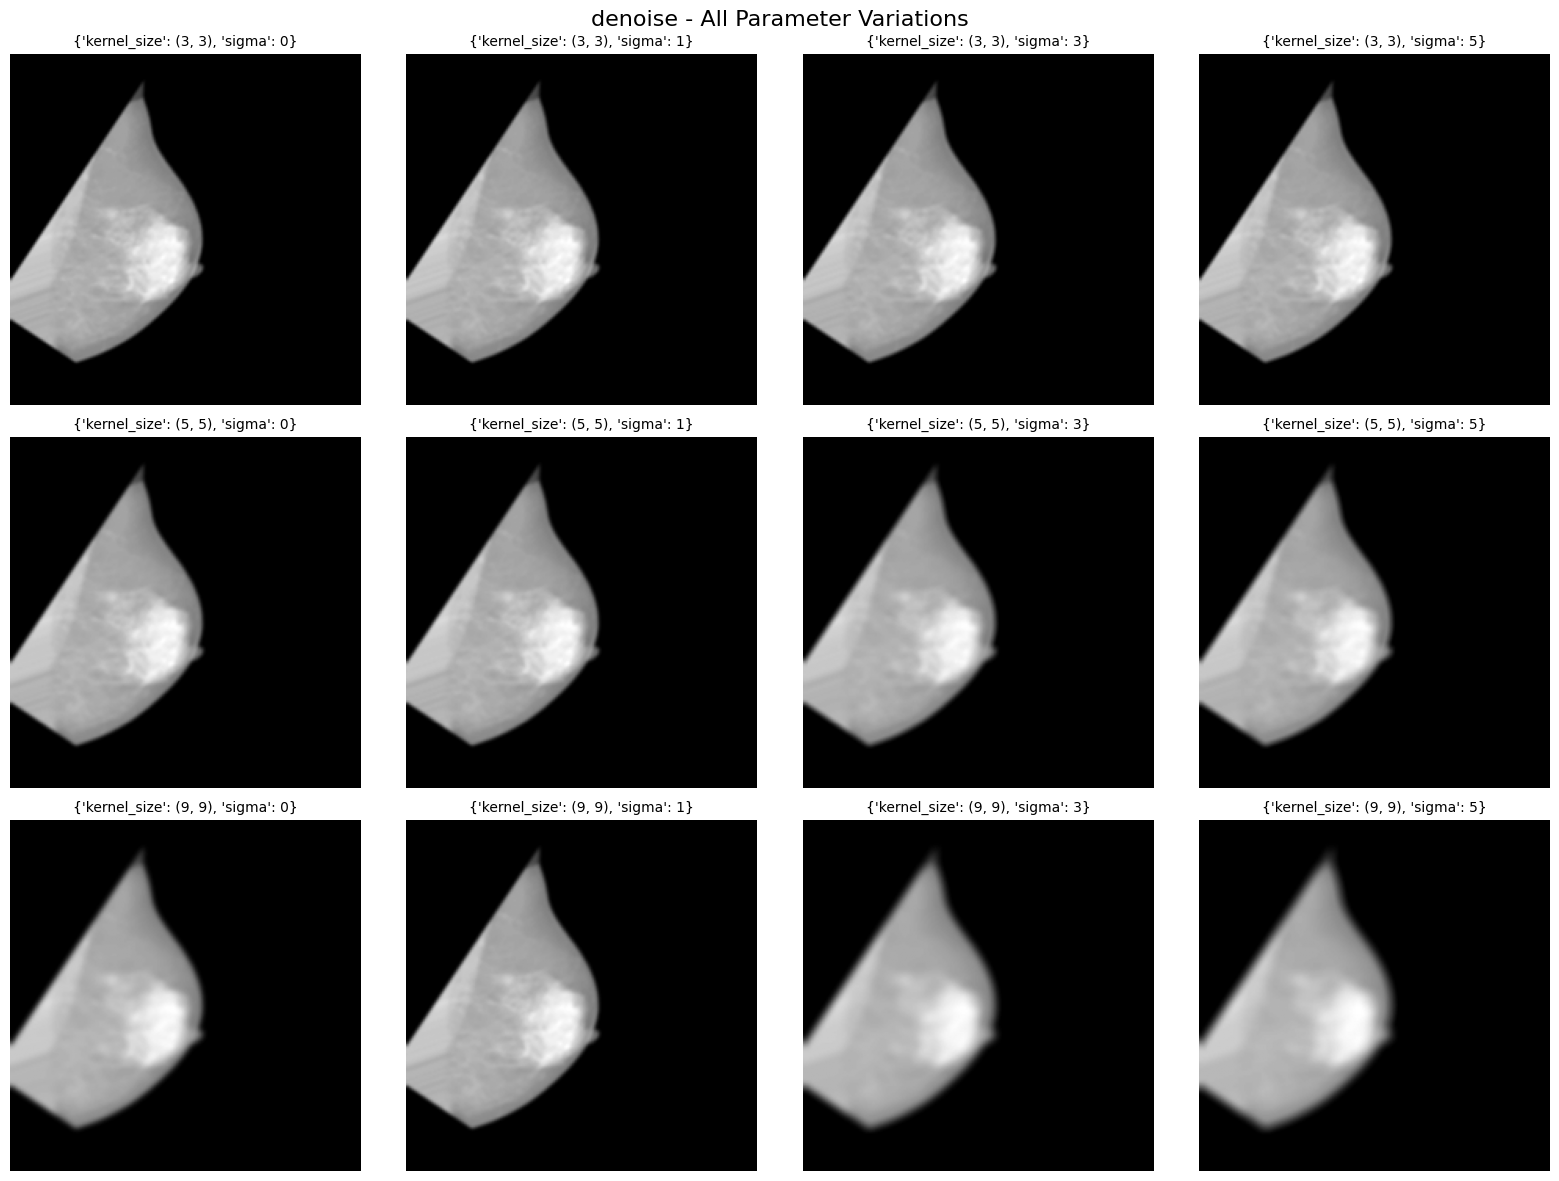

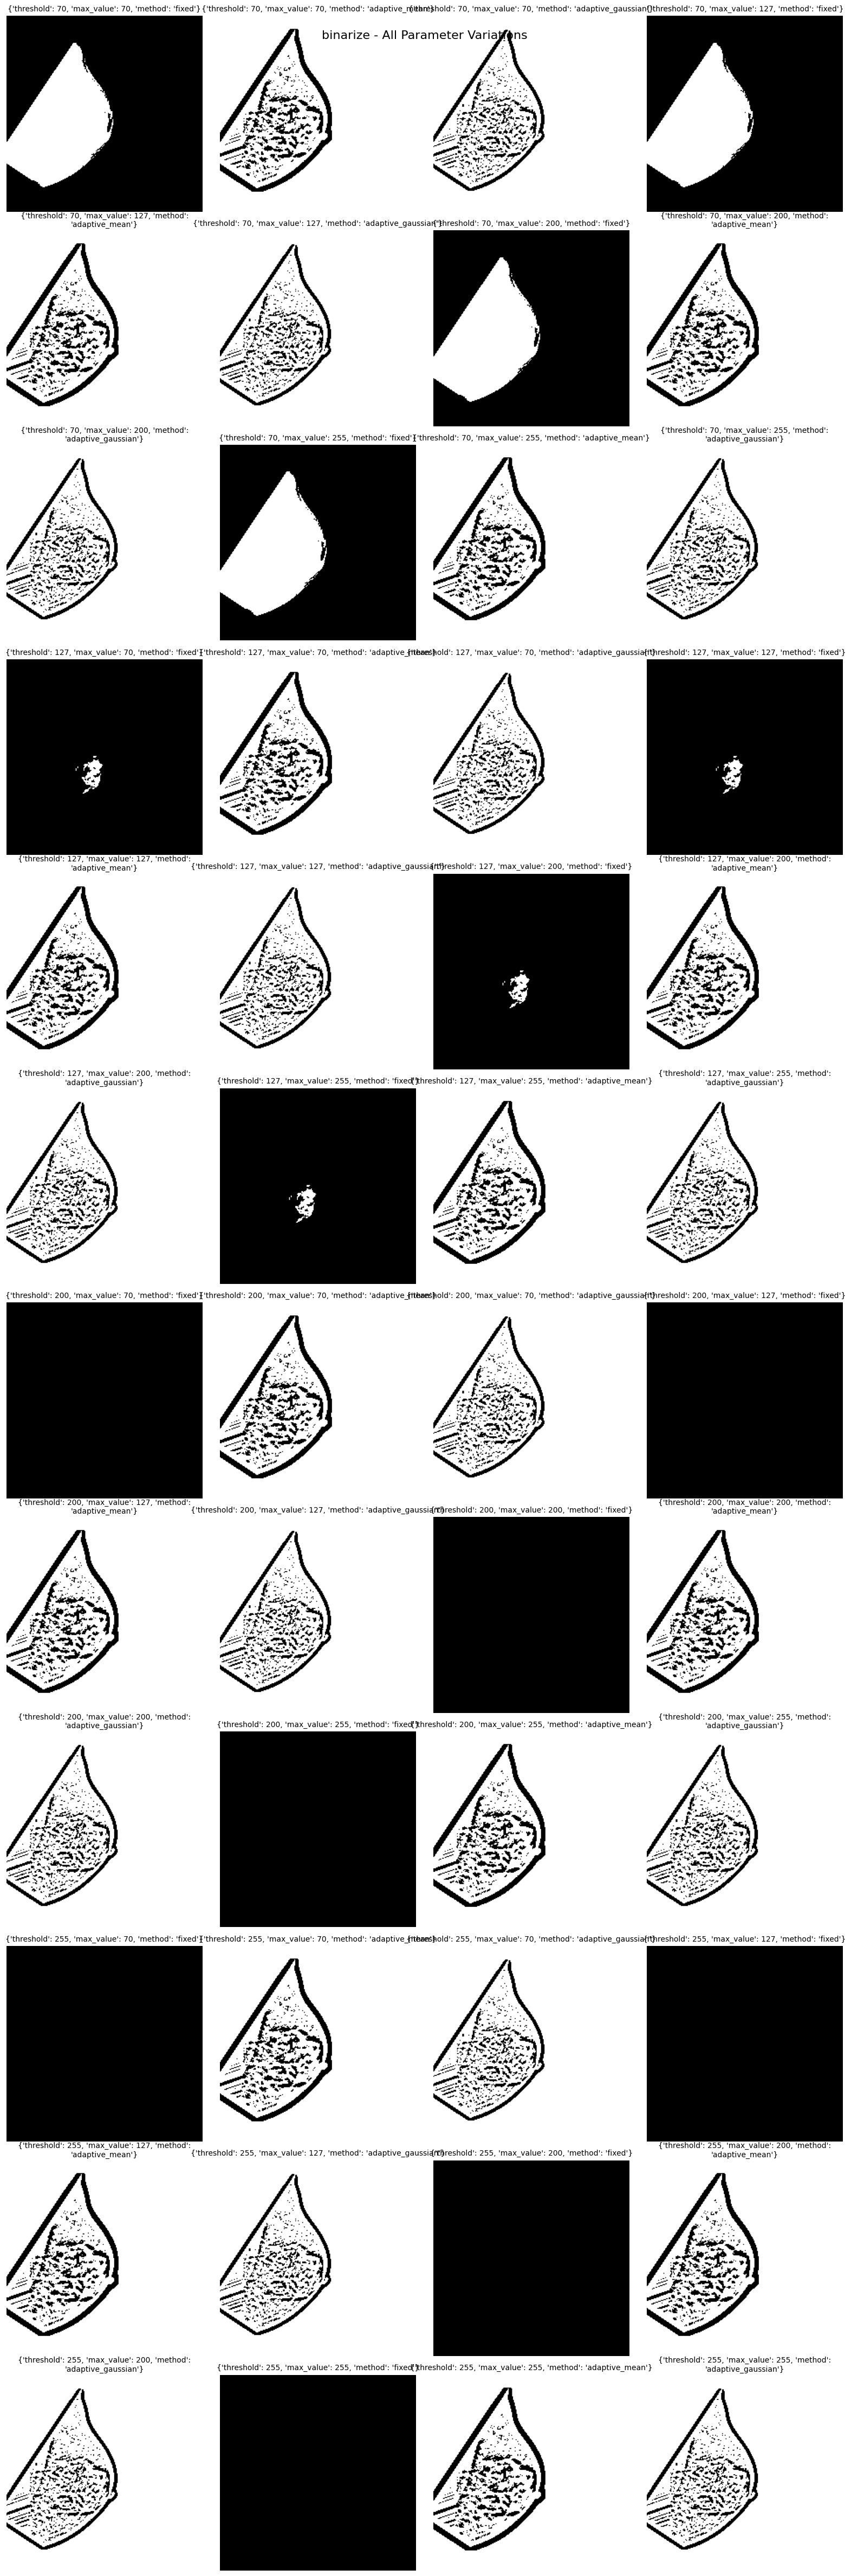

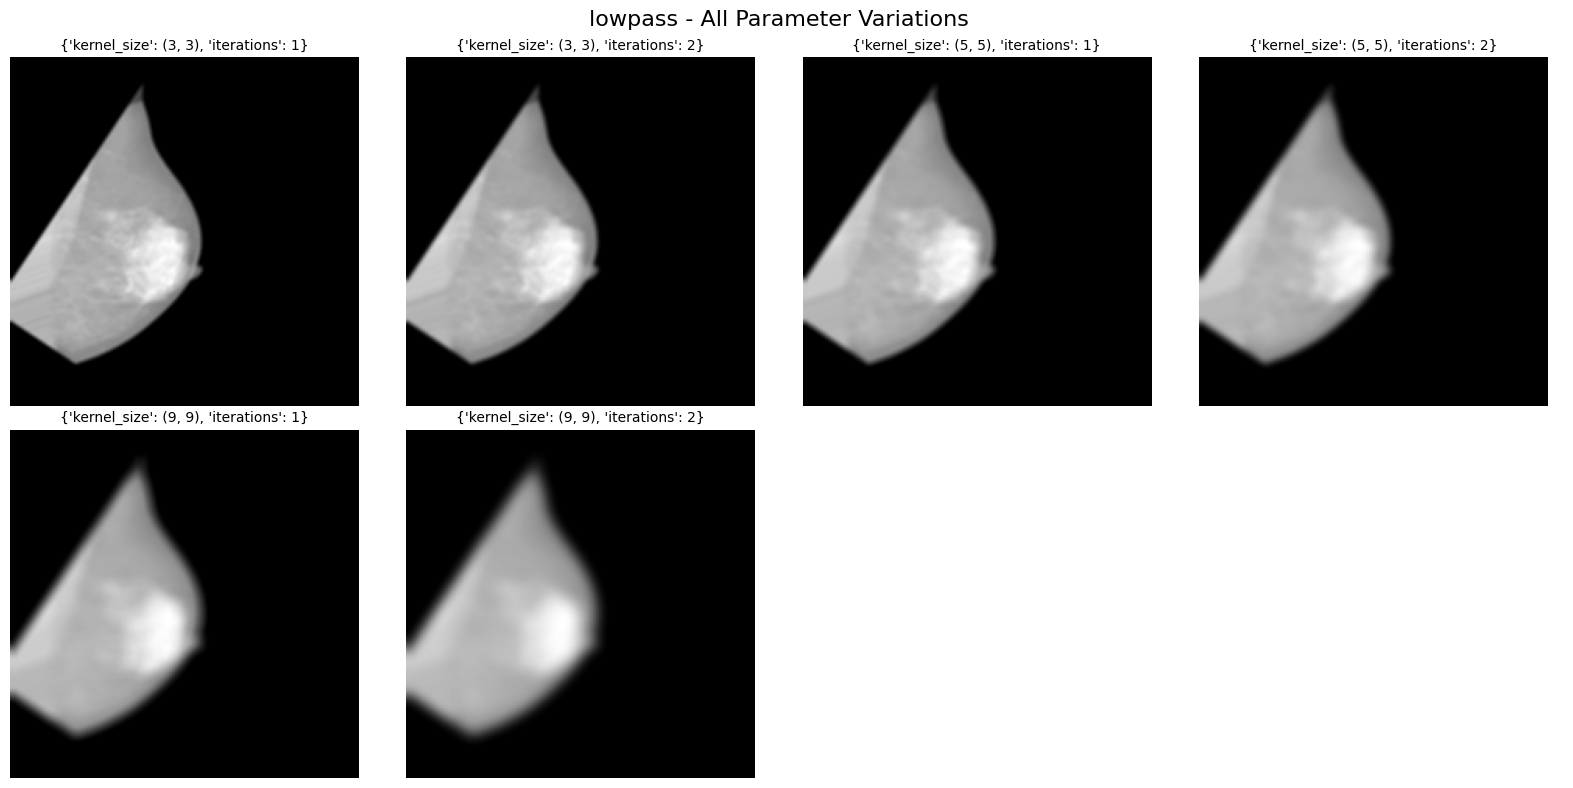

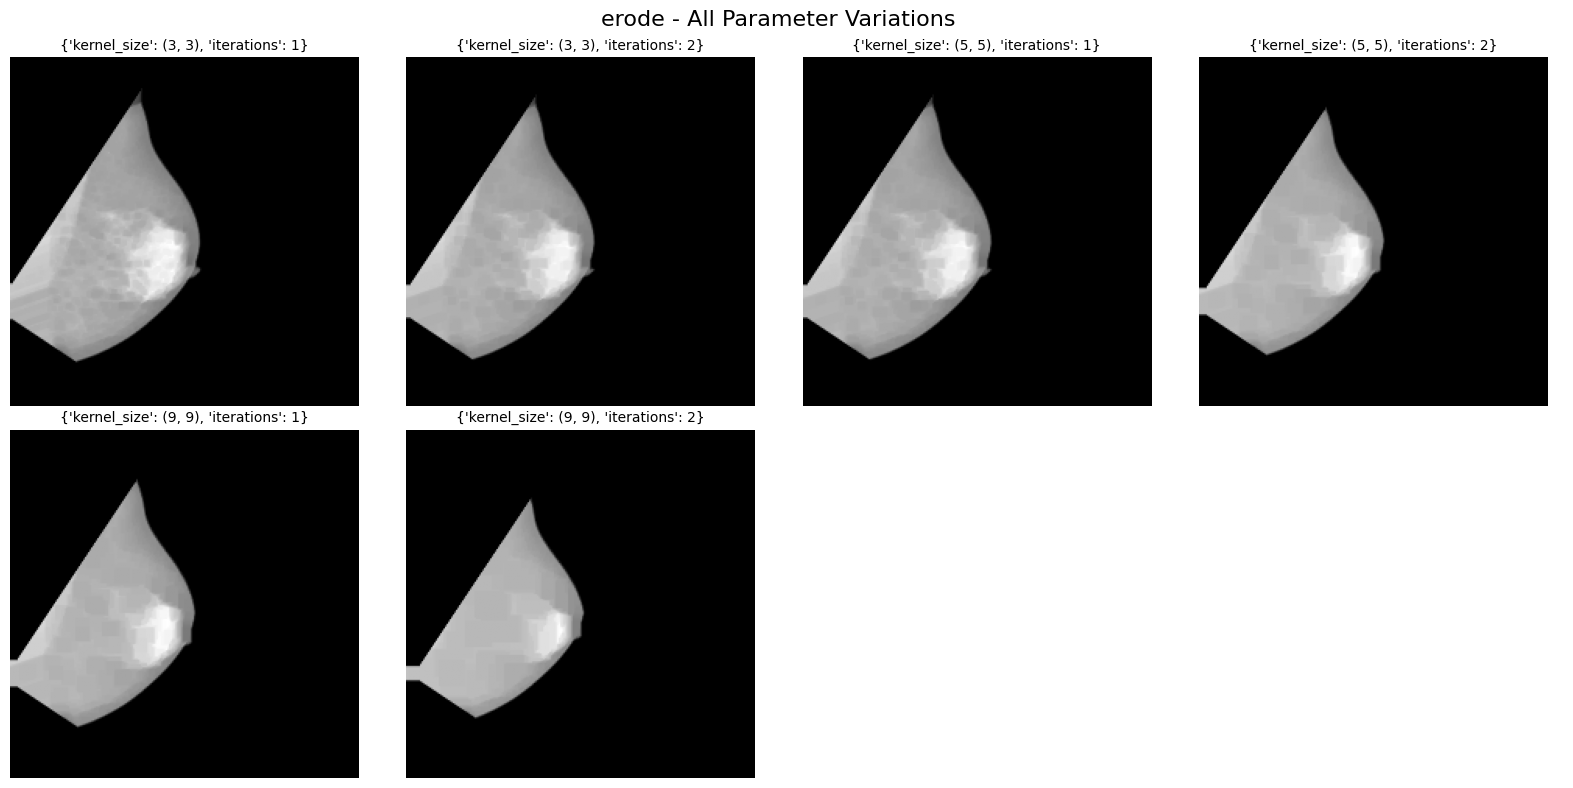

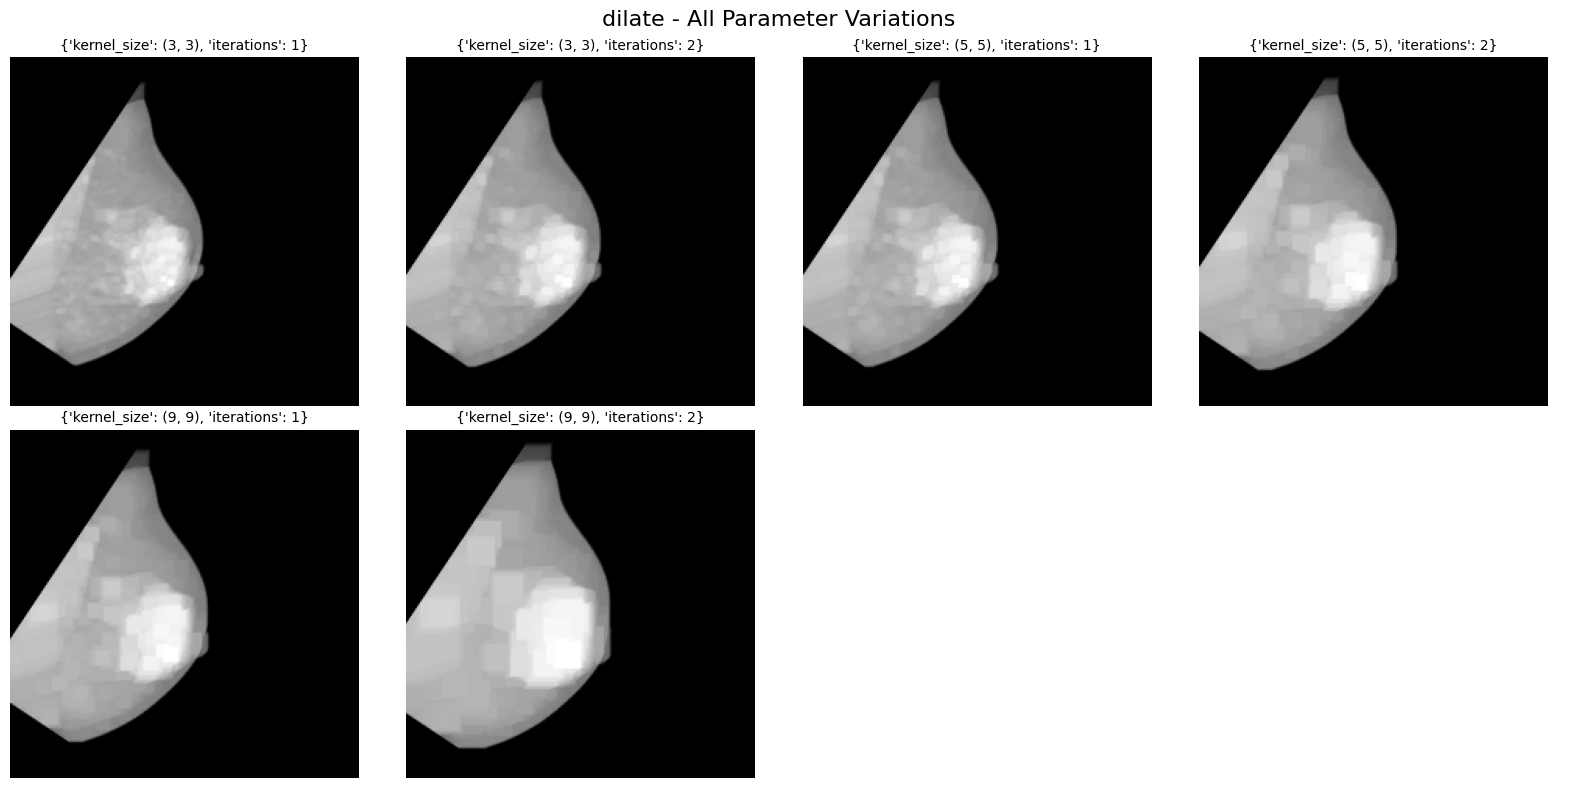

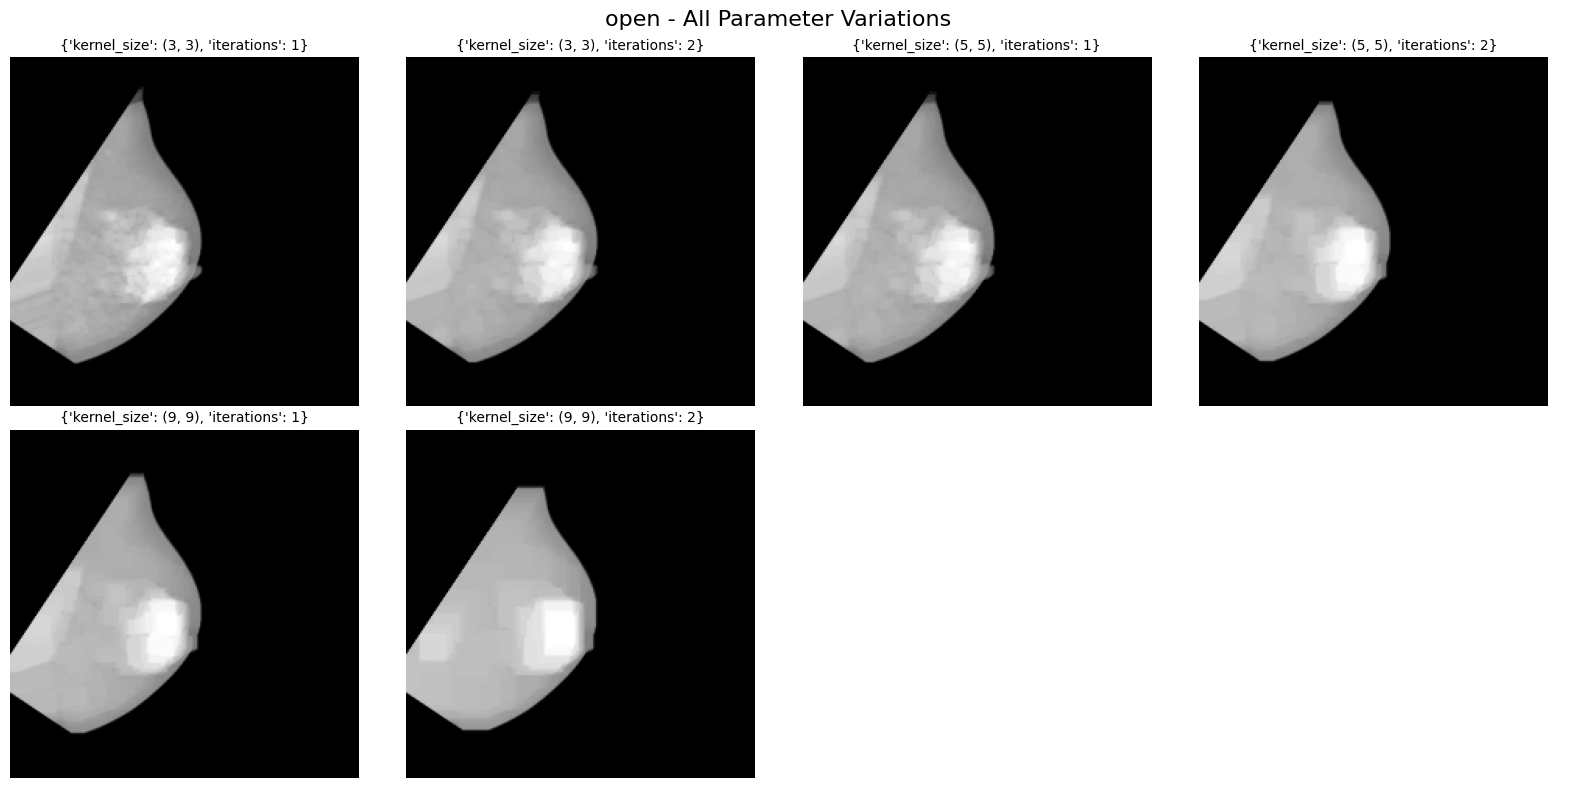

In [22]:
import sys
sys.path.append('../utils')
sys.path.append('..')

import pandas as pd
import cv2
import matplotlib.pyplot as plt
from itertools import product
from utils.preprocessing import preprocessing_methods

# load a random image from train_split.csv
df_preview = pd.read_csv('../data/train_split.csv')
img_path = df_preview.sample(1)['image_path'].values[0]
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# only show single-step methods (skip combined ones)
single_methods = {k: v for k, v in preprocessing_methods.items() if '__' not in k}

for method_name, info in single_methods.items():
    param_names = list(info['params'].keys())
    param_values = [info['params'][k] for k in param_names]
    param_combos = list(product(*param_values))
    n_combos = len(param_combos)
    n_cols = 4
    n_rows = (n_combos + n_cols - 1) // n_cols

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.flatten()
    fig.suptitle(f"{method_name} - All Parameter Variations", fontsize=16)

    for ax, combo in zip(axes, param_combos):
        param_dict = dict(zip(param_names, combo))
        try:
            processed = info['func'](img, **param_dict)
            ax.imshow(processed, cmap='gray')
            ax.set_title(str(param_dict), fontsize=10, wrap=True)
            ax.axis('off')
        except Exception as e:
            ax.set_title(f"Error\n{param_dict}", fontsize=10)
            ax.axis('off')

    for ax in axes[n_combos:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [23]:
all_results = []
for preproc_id in os.listdir(RESULTS_DIR):
    preproc_path = os.path.join(RESULTS_DIR, preproc_id)
    if not os.path.isdir(preproc_path):
        continue
    for model_name in os.listdir(preproc_path):
        model_path = os.path.join(preproc_path, model_name)
        if not os.path.isdir(model_path):
            continue
        for file in os.listdir(model_path):
            if file.endswith('.csv'):
                df = pd.read_csv(os.path.join(model_path, file))
                df['preproc_id'] = preproc_id
                df['model_name'] = model_name
                df['param_combo'] = file.replace('history_', '').replace('.csv', '')
                all_results.append(df)
                
results_df = pd.concat(all_results, ignore_index=True)
print(f"Total results loaded: {len(results_df)}")
print(f"Unique preprocessing methods: {results_df['preproc_id'].nunique()}")
print(f"Unique models: {results_df['model_name'].nunique()}")
print(f"Unique parameter combinations: {results_df['param_combo'].nunique()}")


Total results loaded: 588
Unique preprocessing methods: 6
Unique models: 7
Unique parameter combinations: 66


In [24]:
def parse_params(param_combo):
    """Parse parameter combinations into separate columns"""
    params = {}
    if pd.isna(param_combo):
        return params
    
    # Split by comma and parse key=value pairs
    for pair in param_combo.split('_'):
        if '=' in pair:
            key, value = pair.split('=', 1)
            # Handle tuple values like (3,3)
            if value.startswith('(') and value.endswith(')'):
                params[key] = value
            else:
                # Try to convert to numeric if possible
                try:
                    params[key] = float(value) if '.' in value else int(value)
                except ValueError:
                    params[key] = value
        elif '-' in pair:
            parts = pair.split('-')
            if len(parts) == 2:
                key, value = parts
                try:
                    params[key] = float(value) if '.' in value else int(value)
                except ValueError:
                    params[key] = value
    return params

# Apply parameter parsing
param_data = results_df['param_combo'].apply(parse_params)
param_df = pd.json_normalize(param_data)
results_df = pd.concat([results_df.reset_index(drop=True), param_df.reset_index(drop=True)], axis=1)

In [25]:
# overall performance analysis
print("\n" + "="*75)
print("OVERALL PERFORMANCE ANALYSIS")
print("="*75)

# top K results
top_k = 20
top_results = results_df.sort_values('best_val_acc', ascending=False).head(top_k)
print(f"\nTop {top_k} Results:")
print(top_results[['preproc_id', 'model_name', 'param_combo', 'best_val_acc', 'best_epoch']].to_string())

# performance by model
print("\n" + "-"*30)
print("Performance by Model:")
model_summary = results_df.groupby('model_name')['best_val_acc'].agg(['count', 'mean', 'max', 'std', 'min']).sort_values('max', ascending=False)
print(model_summary)

# performance by preprocessing method
print("\n" + "-"*30)
print("Performance by Preprocessing Method:")
preproc_summary = results_df.groupby('preproc_id')['best_val_acc'].agg(['count', 'mean', 'max', 'std', 'min']).sort_values('max', ascending=False)
print(preproc_summary)


OVERALL PERFORMANCE ANALYSIS

Top 20 Results:
    preproc_id model_name                                          param_combo  best_val_acc  best_epoch
580       open     nasnet                       kernel_size-(9_9)_iterations-1      0.367647          10
375    denoise  inception                            kernel_size-(3_3)_sigma-5      0.318841          10
451     dilate     nasnet                       kernel_size-(3_3)_iterations-2      0.308824          14
579       open     nasnet                       kernel_size-(5_5)_iterations-2      0.308824          14
480      erode  inception                       kernel_size-(3_3)_iterations-1      0.308824           3
379    denoise  inception                            kernel_size-(5_5)_sigma-5      0.304348           2
405    denoise     nasnet                            kernel_size-(9_9)_sigma-1      0.304348          15
535    lowpass     nasnet                       kernel_size-(3_3)_iterations-2      0.294118          13
380    d

In [26]:
# parameter-specific Analysis
print("\n" + "="*75)
print("PARAMETER-SPECIFIC ANALYSIS")
print("="*75)

# Analyze individual parameters
param_columns = [col for col in results_df.columns if col not in ['fold', 'best_val_acc', 'best_epoch', 'preproc_id', 'model_name', 'param_combo'] and not col.startswith('val_') and not col.startswith('loss') and not col.startswith('accuracy')]

for param in param_columns:
    if results_df[param].notna().sum() > 10:  # Only analyze if we have enough data
        print(f"\n--- Analysis for parameter: {param} ---")
        param_analysis = results_df.dropna(subset=[param]).groupby(param)['best_val_acc'].agg(['count', 'mean', 'max', 'std']).sort_values('max', ascending=False)
        print(param_analysis)


PARAMETER-SPECIFIC ANALYSIS

--- Analysis for parameter: auc ---
          count      mean       max  std
auc                                     
0.609981      1  0.367647  0.367647  NaN
0.663906      1  0.318841  0.318841  NaN
0.716014      1  0.308824  0.308824  NaN
0.548877      1  0.308824  0.308824  NaN
0.665639      1  0.308824  0.308824  NaN
...         ...       ...       ...  ...
0.499631      1  0.132353  0.132353  NaN
0.504629      1  0.132353  0.132353  NaN
0.510505      1  0.130435  0.130435  NaN
0.522279      1  0.130435  0.130435  NaN
0.473096      1  0.130435  0.130435  NaN

[585 rows x 4 columns]

--- Analysis for parameter: precision ---
           count      mean       max       std
precision                                     
0.333333      27  0.233250  0.367647  0.050753
0.571429       4  0.288310  0.318841  0.024481
1.000000      13  0.206325  0.308824  0.053098
0.159091       1  0.308824  0.308824       NaN
0.500000      39  0.217960  0.304348  0.040891
...  

In [27]:
# preprocessing Method Deep Dive
print("\n" + "="*75)
print("PREPROCESSING METHOD ANALYSIS")
print("="*75)

for preproc_id in results_df['preproc_id'].unique():
    if '__' not in preproc_id:  # Single preprocessing methods first
        subset = results_df[results_df['preproc_id'] == preproc_id]
        if len(subset) > 5:  # Only analyze if we have enough samples
            print(f"\n--- {preproc_id.upper()} Analysis ---")
            print(f"Total combinations tested: {len(subset)}")
            print(f"Best accuracy: {subset['best_val_acc'].max():.4f}")
            print(f"Mean accuracy: {subset['best_val_acc'].mean():.4f}")
            print(f"Std accuracy: {subset['best_val_acc'].std():.4f}")
            print(f"Best epoch: {subset['best_epoch'].mode()[0]}")
            
            best_combo = subset.loc[subset['best_val_acc'].idxmax()]
            print(f"Best combination: {best_combo['param_combo']}")
            print(f"Best model: {best_combo['model_name']}")
            
            # Top K Categorical Accuracy analysis
            if 'top_k_accuracy' in subset.columns:
                print(f"Best Top-K Categorical Accuracy: {subset['top_k_accuracy'].max():.4f}")
                print(f"Mean Top-K Categorical Accuracy: {subset['top_k_accuracy'].mean():.4f}")
                print(f"Std Top-K Categorical Accuracy: {subset['top_k_accuracy'].std():.4f}")
                topk_best = subset.loc[subset['top_k_accuracy'].idxmax()]
                print(f"Best Top-K Combo: {topk_best['param_combo']} (Model: {topk_best['model_name']})")


PREPROCESSING METHOD ANALYSIS

--- BINARIZE Analysis ---
Total combinations tested: 336
Best accuracy: 0.2899
Mean accuracy: 0.1947
Std accuracy: 0.0413
Best epoch: 1
Best combination: threshold-70_max_value-200_method-fixed
Best model: inception
Best Top-K Categorical Accuracy: 0.8689
Mean Top-K Categorical Accuracy: 0.6757
Std Top-K Categorical Accuracy: 0.0728
Best Top-K Combo: threshold-200_max_value-70_method-adaptive_mean (Model: inception)

--- DENOISE Analysis ---
Total combinations tested: 84
Best accuracy: 0.3188
Mean accuracy: 0.2021
Std accuracy: 0.0517
Best epoch: 10
Best combination: kernel_size-(3_3)_sigma-5
Best model: inception
Best Top-K Categorical Accuracy: 0.8932
Mean Top-K Categorical Accuracy: 0.6961
Std Top-K Categorical Accuracy: 0.0890
Best Top-K Combo: kernel_size-(5_5)_sigma-5 (Model: nasnet)

--- DILATE Analysis ---
Total combinations tested: 42
Best accuracy: 0.3088
Mean accuracy: 0.2045
Std accuracy: 0.0545
Best epoch: 13
Best combination: kernel_size-(3

In [28]:
# top-K label frequency analysis for each model/preprocessing/param combo

K = 3  # top K
topk_label_stats = []

for idx, row in results_df.iterrows():
    # build prediction CSV path (adjust if needed)
    pred_csv = os.path.join(
        PREDICTIONS_DIR,
        row['preproc_id'],
        row['model_name'],
        f"{row['param_combo']}.csv"
    )
    if not os.path.exists(pred_csv):
        continue

    df_pred = pd.read_csv(pred_csv)
    num_classes = len([col for col in df_pred.columns if col.startswith('prob_class_')])
    prob_cols = [f'prob_class_{i}' for i in range(num_classes)]
    probs = df_pred[prob_cols].values

    # get top K predicted class indices for each sample
    top_k_indices = np.argsort(probs, axis=1)[:, -K:]

    # count frequency of each label in top K predictions
    unique, counts = np.unique(top_k_indices, return_counts=True)
    class_freq = dict(zip(unique, counts))

    in_top_k = [row['y_true'] in top_k for row, top_k in zip(df_pred.to_dict('records'), top_k_indices)]
    top_k_accuracy = np.mean(in_top_k)

    topk_label_stats.append({
        'preproc_id': row['preproc_id'],
        'model_name': row['model_name'],
        'param_combo': row['param_combo'],
        'class_freq': class_freq,
        'top_k_accuracy': top_k_accuracy
    })

for stat in topk_label_stats:
    print(f"\nPreproc: {stat['preproc_id']} | Model: {stat['model_name']} | Params: {stat['param_combo']}")
    print(f"Top-{K} categorical accuracy: {stat['top_k_accuracy']:.4f}")
    print("Class frequencies in top K predictions:", stat['class_freq'])


Preproc: binarize | Model: custom cnn | Params: threshold-127_max_value-127_method-adaptive_gaussian
Top-3 categorical accuracy: 0.3824
Class frequencies in top K predictions: {1: 68, 3: 60, 4: 68, 5: 8}

Preproc: binarize | Model: custom cnn | Params: threshold-127_max_value-127_method-adaptive_mean
Top-3 categorical accuracy: 0.3824
Class frequencies in top K predictions: {1: 1, 3: 67, 4: 68, 5: 68}

Preproc: binarize | Model: custom cnn | Params: threshold-127_max_value-127_method-fixed
Top-3 categorical accuracy: 0.3824
Class frequencies in top K predictions: {1: 68, 5: 68, 6: 68}

Preproc: binarize | Model: custom cnn | Params: threshold-127_max_value-200_method-adaptive_gaussian
Top-3 categorical accuracy: 0.3971
Class frequencies in top K predictions: {1: 68, 2: 65, 4: 68, 5: 3}

Preproc: binarize | Model: custom cnn | Params: threshold-127_max_value-200_method-adaptive_mean
Top-3 categorical accuracy: 0.3971
Class frequencies in top K predictions: {1: 68, 2: 10, 4: 68, 5: 58}


In [29]:
# sort by top_k_accuracy
sorted_stats = sorted(topk_label_stats, key=lambda x: x['top_k_accuracy'], reverse=True)

# calculate differentiation score (e.g., number of unique classes in top K)
for stat in sorted_stats:
    stat['class_diversity'] = len(stat['class_freq'])

# pick models with highest accuracy and highest class diversity
best_stats = sorted(sorted_stats, key=lambda x: (x['top_k_accuracy'], x['class_diversity']), reverse=True)

# show top N
for stat in best_stats[:5]:
    print(f"\nPreproc: {stat['preproc_id']} | Model: {stat['model_name']} | Params: {stat['param_combo']}")
    print(f"Top-{K} categorical accuracy: {stat['top_k_accuracy']:.4f}")
    print(f"Class diversity: {stat['class_diversity']}")
    print("Class frequencies in top K predictions:", stat['class_freq'])



Preproc: denoise | Model: inception | Params: kernel_size-(3_3)_sigma-0
Top-3 categorical accuracy: 0.6176
Class diversity: 8
Class frequencies in top K predictions: {0: 28, 1: 17, 2: 36, 3: 35, 4: 22, 5: 12, 6: 32, 7: 22}

Preproc: binarize | Model: inception | Params: threshold-255_max_value-70_method-adaptive_gaussian
Top-3 categorical accuracy: 0.5882
Class diversity: 8
Class frequencies in top K predictions: {0: 23, 1: 24, 2: 24, 3: 32, 4: 19, 5: 29, 6: 25, 7: 28}

Preproc: denoise | Model: inception | Params: kernel_size-(5_5)_sigma-1
Top-3 categorical accuracy: 0.5735
Class diversity: 8
Class frequencies in top K predictions: {0: 30, 1: 23, 2: 16, 3: 25, 4: 36, 5: 22, 6: 31, 7: 21}

Preproc: denoise | Model: inception | Params: kernel_size-(9_9)_sigma-0
Top-3 categorical accuracy: 0.5735
Class diversity: 8
Class frequencies in top K predictions: {0: 25, 1: 32, 2: 23, 3: 24, 4: 21, 5: 33, 6: 27, 7: 19}

Preproc: denoise | Model: inception | Params: kernel_size-(9_9)_sigma-1
Top-